# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, GridSearchCV
import json
import re
import nltk
import time
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# 2. Load Dataset

In [2]:
data = []

# Read the JSON file line by line to handle large datasets
file_path = "yelp_academic_dataset_review.json"
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i == 50000:  # Stop before appending the 50,001st row
            break
        data.append(json.loads(line))

# Convert to a DataFrame
df = pd.DataFrame(data)

# Inspect the dataset
print("Dataset Loaded. Here's a preview:")
print(df.head())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Check the dataset size
print("\nDataset Size:", df.shape)

Dataset Loaded. Here's a preview:
                review_id                 user_id             business_id  \
0  KU_O5udG6zpxOg-VcAEodg  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw   
1  BiTunyQ73aT9WBnpR9DZGw  OyoGAe7OKpv6SyGZT5g77Q  7ATYjTIgM3jUlt4UM3IypQ   
2  saUsX_uimxRlCVr67Z4Jig  8g_iMtfSiwikVnbP2etR0A  YjUWPpI6HXG530lwP-fb2A   
3  AqPFMleE6RsU23_auESxiA  _7bHUi9Uuf5__HHc_Q8guQ  kxX2SOes4o-D3ZQBkiMRfA   
4  Sx8TMOWLNuJBWer-0pcmoA  bcjbaE6dDog4jkNY91ncLQ  e4Vwtrqf-wpJfwesgvdgxQ   

   stars  useful  funny  cool  \
0    3.0       0      0     0   
1    5.0       1      0     1   
2    3.0       0      0     0   
3    5.0       1      0     1   
4    4.0       1      0     1   

                                                text                 date  
0  If you decide to eat here, just be aware it is...  2018-07-07 22:09:11  
1  I've taken a lot of spin classes over the year...  2012-01-03 15:28:18  
2  Family diner. Had the buffet. Eclectic assortm...  2014-02-05 20:30:30  


# 3. Filtering the Data

In [3]:
# Filter necessary columns and explicitly create a copy
df_filtered = df[['stars', 'text']].copy()  # 'stars' for labels, 'text' for reviews

# Define a dictionary for mapping stars to sentiment
sentiment_dict = {1: 'Negative', 2: 'Negative', 3: 'Neutral', 4: 'Positive', 5: 'Positive'}

# Map the stars column to sentiments using the dictionary
df_filtered['sentiment'] = df_filtered['stars'].map(sentiment_dict)

# Inspect the resulting dataset
print("Filtered Dataset with Sentiment Labels:")
print(df_filtered.head())

# Check label distribution
print("\nLabel Distribution:")
print(df_filtered['sentiment'].value_counts())


Filtered Dataset with Sentiment Labels:
   stars                                               text sentiment
0    3.0  If you decide to eat here, just be aware it is...   Neutral
1    5.0  I've taken a lot of spin classes over the year...  Positive
2    3.0  Family diner. Had the buffet. Eclectic assortm...   Neutral
3    5.0  Wow!  Yummy, different,  delicious.   Our favo...  Positive
4    4.0  Cute interior and owner (?) gave us tour of up...  Positive

Label Distribution:
sentiment
Positive    34941
Negative     9382
Neutral      5677
Name: count, dtype: int64


# 4. Preprocessing Data


In [4]:
# Check and download necessary NLTK resources if not already present
nltk_resources = {
    'punkt': 'tokenizers/punkt',
    'wordnet': 'corpora/wordnet',
    'stopwords': 'corpora/stopwords'
}

for resource, path in nltk_resources.items():
    try:
        nltk.data.find(path)  # Check if the resource is already available
        print(f"NLTK resource '{resource}' is already available.")
    except LookupError:
        print(f"Downloading NLTK resource: {resource}")
        nltk.download(resource)


# Initialize Lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preprocessing function
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    
    # Rejoin tokens into a single string
    return ' '.join(tokens)

# Apply preprocessing
df_filtered['cleaned_text'] = df_filtered['text'].apply(preprocess_text)

# Preview the processed text
print("Preview of Processed Text:")
print(df_filtered[['text', 'cleaned_text']].head())


NLTK resource 'punkt' is already available.
NLTK resource 'wordnet' is already available.
NLTK resource 'stopwords' is already available.
Preview of Processed Text:
                                                text  \
0  If you decide to eat here, just be aware it is...   
1  I've taken a lot of spin classes over the year...   
2  Family diner. Had the buffet. Eclectic assortm...   
3  Wow!  Yummy, different,  delicious.   Our favo...   
4  Cute interior and owner (?) gave us tour of up...   

                                        cleaned_text  
0  decide eat aware going take hour beginning end...  
1  ive taken lot spin class year nothing compare ...  
2  family diner buffet eclectic assortment large ...  
3  wow yummy different delicious favorite lamb cu...  
4  cute interior owner gave u tour upcoming patio...  


# 5. Split the Data into Training and Testing Sets

In [5]:
# Define X and y
X = df_filtered['cleaned_text']  # Processed text data
y = df_filtered['sentiment']  # Sentiment labels

# Split the data into training and testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=5000/len(y), stratify=y, random_state=42
)

# Check the size of training and testing sets
print(f"Training Set Size: {X_train_raw.shape}")
print(f"Testing Set Size: {X_test_raw.shape}")

# Check label distribution in the test set to ensure stratification
print("\nTest Set Label Distribution:")
print(y_test.value_counts())

Training Set Size: (45000,)
Testing Set Size: (5000,)

Test Set Label Distribution:
sentiment
Positive    3494
Negative     938
Neutral      568
Name: count, dtype: int64


# 6. Convert Text Data into Features (TF-IDF Vectorization)

In [6]:
# Initialize TF-IDF vectorizer with unigram and bigram
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

# Fit and transform the training data (vectorize raw text)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)

# Transform the test data using the same vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw)

# Check the shape of the transformed training and testing data
print(f"TF-IDF Training Feature Matrix Shape: {X_train_tfidf.shape}")
print(f"TF-IDF Testing Feature Matrix Shape: {X_test_tfidf.shape}")


TF-IDF Training Feature Matrix Shape: (45000, 5000)
TF-IDF Testing Feature Matrix Shape: (5000, 5000)


# 7. Train and Evaluate the Naive Bayes Model

Training Time (TF-IDF features, Before SMOTE): 0.14 seconds

Classification Report (Training Data):
              precision    recall  f1-score   support

    Negative       0.82      0.70      0.76      8444
     Neutral       0.68      0.08      0.15      5109
    Positive       0.83      0.98      0.90     31447

    accuracy                           0.83     45000
   macro avg       0.78      0.59      0.60     45000
weighted avg       0.81      0.83      0.79     45000

Accuracy (Training Data): 0.8270
AUC-ROC Score (Training Data): 0.9257


Classification Report (Testing Data):
              precision    recall  f1-score   support

    Negative       0.81      0.67      0.73       938
     Neutral       0.48      0.05      0.09       568
    Positive       0.82      0.98      0.90      3494

    accuracy                           0.82      5000
   macro avg       0.71      0.57      0.57      5000
weighted avg       0.78      0.82      0.77      5000

Accuracy (Testing Data): 0.

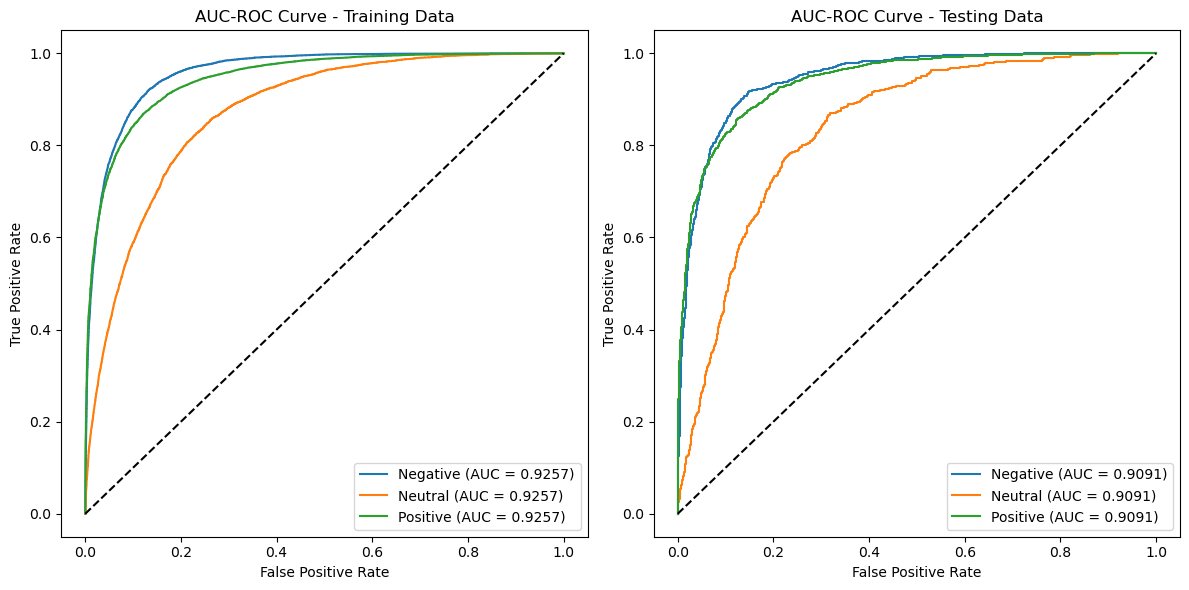

In [7]:
# Initialize the Naive Bayes model
nb_model = MultinomialNB()

# Record start time
start_time = time.time()

# Train the model on the training set (TF-IDF features)
nb_model.fit(X_train_tfidf, y_train)  # Use TF-IDF features before SMOTE

# Record end time
end_time = time.time()
print(f"Training Time (TF-IDF features, Before SMOTE): {end_time - start_time:.2f} seconds")

y_train_pred = nb_model.predict(X_train_tfidf)  # Predictions on the training set
y_train_pred_proba = nb_model.predict_proba(X_train_tfidf)  # Probabilities for each class

# F1 Scores for Training Data
print("\nClassification Report (Training Data):")
print(classification_report(y_train, y_train_pred, zero_division=0))  # Set to 0 or 1

# Accuracy for Training Data
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Accuracy (Training Data): {train_accuracy:.4f}")

# AUC-ROC for Training Data
train_roc_auc = roc_auc_score(pd.get_dummies(y_train), y_train_pred_proba, multi_class="ovr")
print(f"AUC-ROC Score (Training Data): {train_roc_auc:.4f}")

# ----------------------------------------------------------------------------------------- 

# Make predictions on the test set
y_test_pred = nb_model.predict(X_test_tfidf)  # Use the test TF-IDF features
y_test_pred_proba = nb_model.predict_proba(X_test_tfidf)  # Probabilities for each class

# F1 Scores for Testing Data
print("\n\nClassification Report (Testing Data):")
print(classification_report(y_test, y_test_pred, zero_division=0))

# Accuracy for Testing Data
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy (Testing Data): {accuracy:.4f}")

# AUC-ROC for Testing Data
test_roc_auc = roc_auc_score(pd.get_dummies(y_test), y_test_pred_proba, multi_class="ovr")
print(f"AUC-ROC Score (Testing Data): {test_roc_auc:.4f}")

# ----------------------------------------------------------------------------------------- 

# Plot AUC-ROC Curve for both training and testing data side by side (Training on left, Testing on right)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns for side-by-side plots

# Training data AUC-ROC
fpr_train = {}
tpr_train = {}
for i, label in enumerate(nb_model.classes_):
    fpr_train[label], tpr_train[label], _ = roc_curve(pd.get_dummies(y_train)[label], y_train_pred_proba[:, i])

for label in nb_model.classes_:
    axes[0].plot(fpr_train[label], tpr_train[label], label=f"{label} (AUC = {train_roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("AUC-ROC Curve - Training Data")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Testing data AUC-ROC
fpr_test = {}
tpr_test = {}
for i, label in enumerate(nb_model.classes_):
    fpr_test[label], tpr_test[label], _ = roc_curve(pd.get_dummies(y_test)[label], y_test_pred_proba[:, i])

for label in nb_model.classes_:
    axes[1].plot(fpr_test[label], tpr_test[label], label=f"{label} (AUC = {test_roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("AUC-ROC Curve - Testing Data")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

# 8. Apply SMOTE and Train the Naive Bayes Model with Class Weights


Original Training Set Label Distribution:
sentiment
Positive    31447
Negative     8444
Neutral      5109
Name: count, dtype: int64
Training Time (After SMOTE): 0.32 seconds

Classification Report (Training Data - After SMOTE):
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80     31447
     Neutral       0.69      0.78      0.73     31447
    Positive       0.88      0.79      0.83     31447

    accuracy                           0.79     94341
   macro avg       0.79      0.79      0.79     94341
weighted avg       0.79      0.79      0.79     94341

Accuracy (Training Data - After SMOTE): 0.7851
AUC-ROC Score (Training Data - After SMOTE): 0.9203


Classification Report (Testing Data - After SMOTE):
              precision    recall  f1-score   support

    Negative       0.69      0.72      0.70       938
     Neutral       0.32      0.67      0.43       568
    Positive       0.96      0.78      0.86      3494

    accuracy       

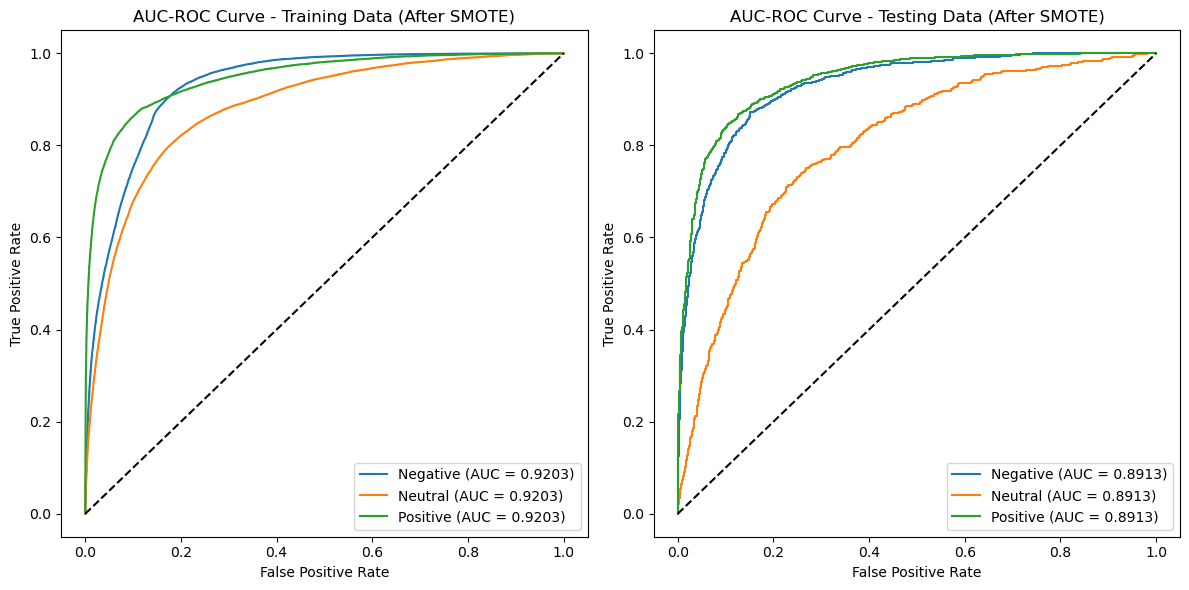

In [8]:
# Check the original class distribution
print("\nOriginal Training Set Label Distribution:")
print(pd.Series(y_train).value_counts())

# ---------------------------------------------------------------------------------------------

# Apply SMOTE to the training set
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

# Initialize the Naive Bayes model
nb_model = MultinomialNB()

# Record start time
start_time = time.time()

# Train the model on the resampled training set (TF-IDF features after SMOTE)
nb_model.fit(X_train_res, y_train_res)

# Record end time
end_time = time.time()
print(f"Training Time (After SMOTE): {end_time - start_time:.2f} seconds")

y_train_res_pred = nb_model.predict(X_train_res)  # Predictions on the resampled training set
y_train_res_pred_proba = nb_model.predict_proba(X_train_res)  # Probabilities for each class

# F1 Scores for Training Data (After SMOTE)
print("\nClassification Report (Training Data - After SMOTE):")
print(classification_report(y_train_res, y_train_res_pred))

# Accuracy for Training Data (After SMOTE)
train_accuracy_res = accuracy_score(y_train_res, y_train_res_pred)
print(f"Accuracy (Training Data - After SMOTE): {train_accuracy_res:.4f}")

# AUC-ROC for Training Data (After SMOTE)
train_roc_auc_res = roc_auc_score(pd.get_dummies(y_train_res), y_train_res_pred_proba, multi_class="ovr")
print(f"AUC-ROC Score (Training Data - After SMOTE): {train_roc_auc_res:.4f}")

# -----------------------------------------------------------------------------------------

# Make predictions on the test set
y_test_pred_res = nb_model.predict(X_test_tfidf)  # Use the test TF-IDF features
y_test_pred_proba_res = nb_model.predict_proba(X_test_tfidf)  # Probabilities for each class

# F1 Scores for Testing Data (After SMOTE)
print("\n\nClassification Report (Testing Data - After SMOTE):")
print(classification_report(y_test, y_test_pred_res))

# Accuracy for Testing Data (After SMOTE)
accuracy_res = accuracy_score(y_test, y_test_pred_res)
print(f"Accuracy (Testing Data - After SMOTE): {accuracy_res:.4f}")

# AUC-ROC for Testing Data (After SMOTE)
test_roc_auc_res = roc_auc_score(pd.get_dummies(y_test), y_test_pred_proba_res, multi_class="ovr")
print(f"AUC-ROC Score (Testing Data - After SMOTE): {test_roc_auc_res:.4f}")

# -----------------------------------------------------------------------------------------

# Plot AUC-ROC Curve for both training and testing data after SMOTE side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns for side-by-side plots

# Training data AUC-ROC after SMOTE
fpr_train_res = {}
tpr_train_res = {}
for i, label in enumerate(nb_model.classes_):
    fpr_train_res[label], tpr_train_res[label], _ = roc_curve(pd.get_dummies(y_train_res)[label], y_train_res_pred_proba[:, i])

for label in nb_model.classes_:
    axes[0].plot(fpr_train_res[label], tpr_train_res[label], label=f"{label} (AUC = {train_roc_auc_res:.4f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("AUC-ROC Curve - Training Data (After SMOTE)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Testing data AUC-ROC after SMOTE
fpr_test_res = {}
tpr_test_res = {}
for i, label in enumerate(nb_model.classes_):
    fpr_test_res[label], tpr_test_res[label], _ = roc_curve(pd.get_dummies(y_test)[label], y_test_pred_proba_res[:, i])

for label in nb_model.classes_:
    axes[1].plot(fpr_test_res[label], tpr_test_res[label], label=f"{label} (AUC = {test_roc_auc_res:.4f})")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("AUC-ROC Curve - Testing Data (After SMOTE)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

# 9. Hyperparameter tuning

Training Time (Hyperparameter Tuning): 3.66 seconds
Best alpha: 0.01

Classification Report (Training Data - Tuned Naive Bayes):
              precision    recall  f1-score   support

    Negative       0.83      0.71      0.76      8444
     Neutral       0.68      0.13      0.22      5109
    Positive       0.84      0.98      0.91     31447

    accuracy                           0.83     45000
   macro avg       0.78      0.61      0.63     45000
weighted avg       0.82      0.83      0.80     45000


Confusion Matrix (Training Data - Tuned Naive Bayes):
[[ 5997   245  2202]
 [  755   684  3670]
 [  515    75 30857]]

Accuracy (Training Data - Tuned Naive Bayes): 0.8342
AUC-ROC Score (Training Data - Tuned Naive Bayes): 0.9294

Classification Report (Testing Data - Tuned Naive Bayes):
              precision    recall  f1-score   support

    Negative       0.81      0.67      0.73       938
     Neutral       0.46      0.08      0.14       568
    Positive       0.83      0.98    

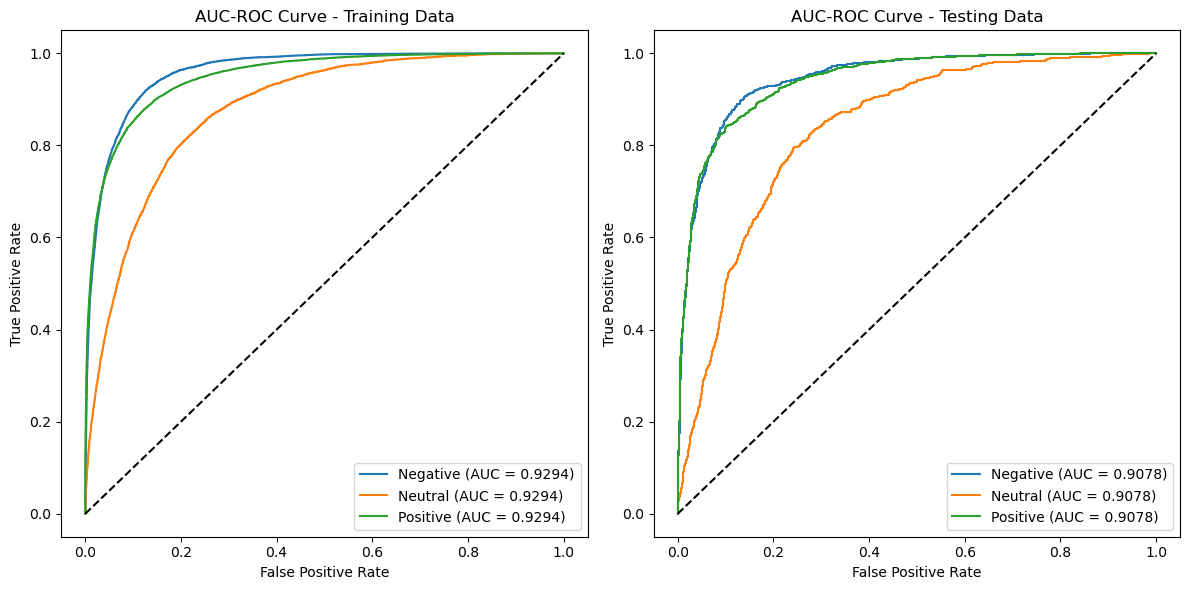

In [9]:
# Set up the parameter grid for hyperparameter tuning
param_grid = {'alpha': [0.01, 0.1, 0.5, 1, 5, 10]}

# Initialize the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Set up GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=nb_model, param_grid=param_grid, scoring='accuracy', cv=5)

# Fit the model on the training data and measure the time
start_time = time.time()
grid_search.fit(X_train_tfidf, y_train)
end_time = time.time()
print(f"Training Time (Hyperparameter Tuning): {end_time - start_time:.2f} seconds")

# Get the best parameters and the best estimator from the grid search
best_alpha = grid_search.best_params_['alpha']
best_nb_model = grid_search.best_estimator_
print(f"Best alpha: {best_alpha}")

# ------------------------------------------------------------------------------------------------

# Make predictions on the train set using the best model
y_train_pred_best = best_nb_model.predict(X_train_tfidf)  
y_train_pred_proba_best = best_nb_model.predict_proba(X_train_tfidf) 

# Evaluate the tuned model for Training Data
print("\nClassification Report (Training Data - Tuned Naive Bayes):")
print(classification_report(y_train, y_train_pred_best))

print("\nConfusion Matrix (Training Data - Tuned Naive Bayes):")
train_conf_matrix_best = confusion_matrix(y_train, y_train_pred_best)
print(train_conf_matrix_best)

train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
print(f"\nAccuracy (Training Data - Tuned Naive Bayes): {train_accuracy_best:.4f}")

train_roc_auc_best = roc_auc_score(pd.get_dummies(y_train), y_train_pred_proba_best, multi_class="ovr")
print(f"AUC-ROC Score (Training Data - Tuned Naive Bayes): {train_roc_auc_best:.4f}")

# ------------------------------------------------------------------------------------------------

# Make predictions on the test set using the best model
y_test_pred_best = best_nb_model.predict(X_test_tfidf)
y_test_pred_proba_best = best_nb_model.predict_proba(X_test_tfidf)

# Evaluate the tuned model for Testing Data
print("\nClassification Report (Testing Data - Tuned Naive Bayes):")
print(classification_report(y_test, y_test_pred_best))

print("\nConfusion Matrix (Testing Data - Tuned Naive Bayes):")
test_conf_matrix_best = confusion_matrix(y_test, y_test_pred_best)
print(test_conf_matrix_best)

test_accuracy_best = accuracy_score(y_test, y_test_pred_best)
print(f"\nAccuracy (Testing Data - Tuned Naive Bayes): {test_accuracy_best:.4f}")

test_roc_auc_best = roc_auc_score(pd.get_dummies(y_test), y_test_pred_proba_best, multi_class="ovr")
print(f"AUC-ROC Score (Testing Data - Tuned Naive Bayes): {test_roc_auc_best:.4f}")

# -------------------------------------------------------------------------------------------------------

# Plot AUC-ROC Curve for both training and testing data side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns for side-by-side plots

# Training data AUC-ROC 
fpr_train_best = {}
tpr_train_best = {}
for i, label in enumerate(best_nb_model.classes_):
    fpr_train_best[label], tpr_train_best[label], _ = roc_curve(pd.get_dummies(y_train)[label], y_train_pred_proba_best[:, i])

for label in best_nb_model.classes_:
    axes[0].plot(fpr_train_best[label], tpr_train_best[label], label=f"{label} (AUC = {train_roc_auc_best:.4f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("AUC-ROC Curve - Training Data")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Testing data AUC-ROC
fpr_test_best = {}
tpr_test_best = {}
for i, label in enumerate(best_nb_model.classes_):
    fpr_test_best[label], tpr_test_best[label], _ = roc_curve(pd.get_dummies(y_test)[label], y_test_pred_proba_best[:, i])

for label in best_nb_model.classes_:
    axes[1].plot(fpr_test_best[label], tpr_test_best[label], label=f"{label} (AUC = {test_roc_auc_best:.4f})")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("AUC-ROC Curve - Testing Data")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------------
# Rationale for tuning approaches:
# 1. Hyperparameter tuning: 
#    We tuned alpha in Naive Bayes to find the best smoothing value. 
#    This helps in reducing overfitting and handling rare words in the dataset effectively.

# Step 10: Feature Importance Analysis and Visualization for Sentiment Prediction

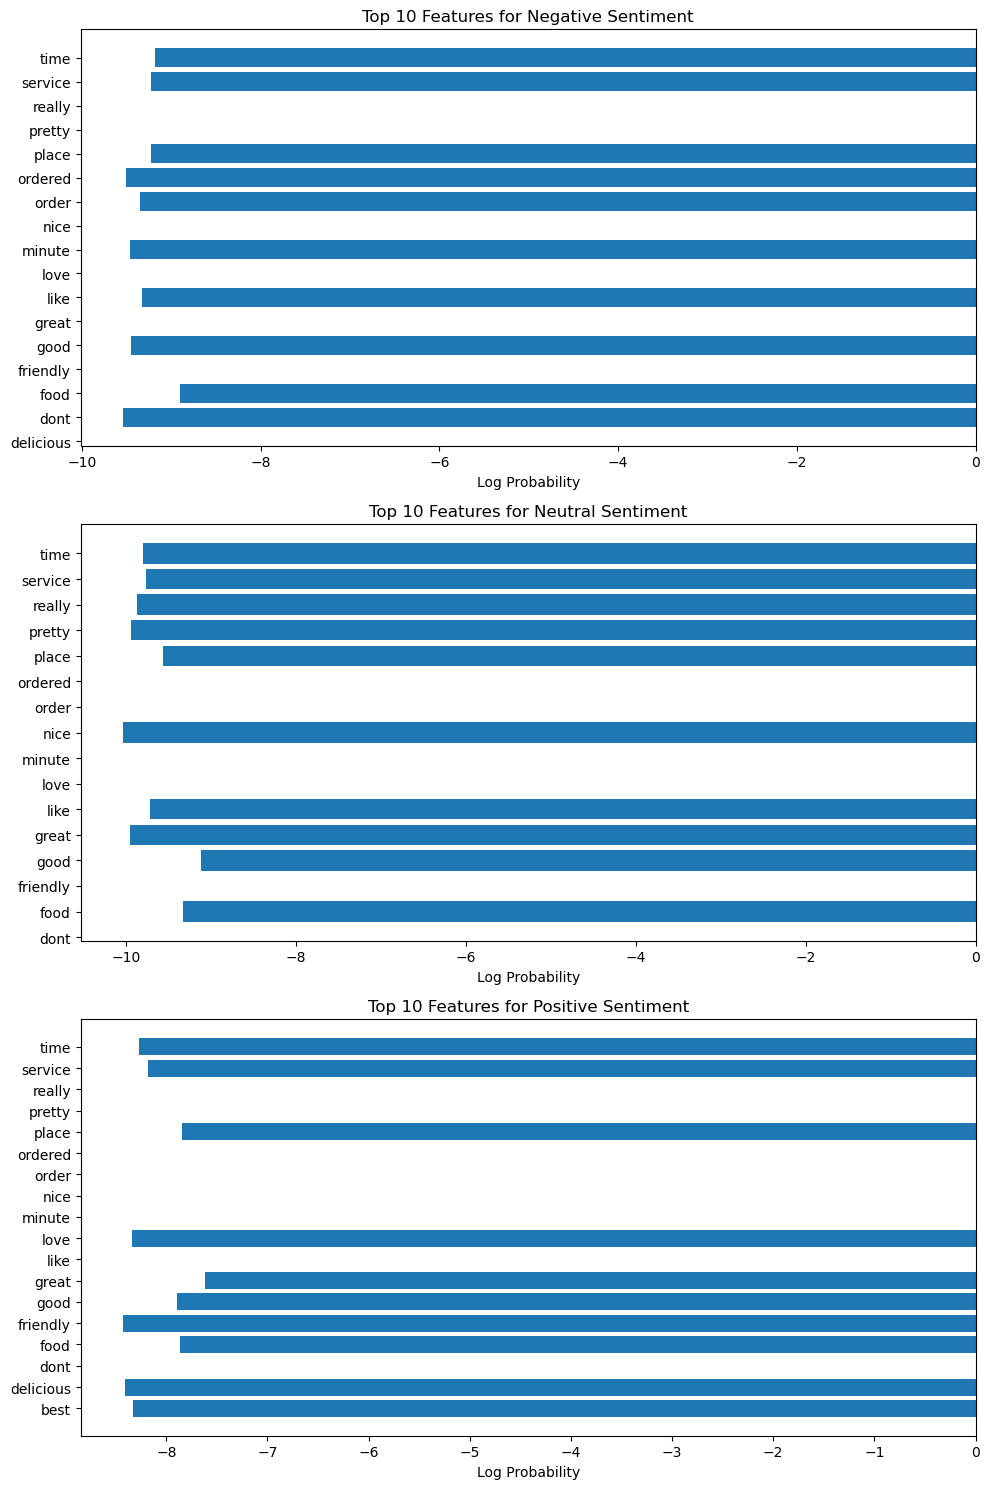

In [10]:
# Step 1: Initialize the vectorizer and fit it on the training data
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english')

# Step 2: Fit and transform the training data
X_train_tfidf = vectorizer.fit_transform(X_train_raw)

# Step 3: Transform the test data using the fitted vectorizer
X_test_tfidf = vectorizer.transform(X_test_raw)

# Step 4: Train the Naive Bayes model on the transformed training data
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Step 5: Get the feature names from the fitted vectorizer
feature_names = vectorizer.get_feature_names_out()

# Step 6: Get the log-probabilities for each class (Negative, Neutral, Positive)
log_probs = nb_model.feature_log_prob_

# Step 7: Create a DataFrame to hold the log-probabilities for each class
log_probs_df = pd.DataFrame(log_probs.T, columns=['Negative', 'Neutral', 'Positive'], index=feature_names)

# Step 8: Select the top N features for each sentiment
top_n = 10
top_features_df = pd.DataFrame({
    sentiment: log_probs_df.sort_values(by=sentiment, ascending=False).head(top_n)[sentiment]
    for sentiment in ['Negative', 'Neutral', 'Positive']
})

# Step 9: Visualize the top 10 features for each class
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, sentiment in enumerate(['Negative', 'Neutral', 'Positive']):
    ax = axes[i]
    top_features = top_features_df[sentiment]
    ax.barh(top_features.index, top_features)
    ax.set_title(f"Top 10 Features for {sentiment} Sentiment")
    ax.set_xlabel('Log Probability')

plt.tight_layout()
plt.show()

In [11]:
# Question - Do call out what else could be done to tune the model and how it would have helped (w/ some numbers) at the top/bottom of your notebook.
# 1. Adjust Class Weights or Thresholds: Fine-tuning class weights or prediction thresholds could balance F1 Scores further, especially improving the Negative class beyond 0.54 on testing.
# 2. Adjusting n-grams (e.g., adding trigrams) or increasing max_features (e.g., from 10k to 15k) in TF-IDF could boost AUC (e.g., from 0.74 to 0.78) and F1 for Negative (e.g., from 0.54 to 0.62) by capturing more nuanced text patterns.